# Project 5B: Flow Matching from Scratch!

## Setup environment

In [ ]:
# We recommend using these utils.
# https://google.github.io/mediapy/mediapy.html
# https://einops.rocks/
!pip install mediapy einops --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.3 MB/s eta 0:00:00


In [5]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from tqdm import tqdm

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
import torch
import mediapy as media

def standardize(img):
  if img.ndim == 4:
    img = img[0]
  if isinstance(img, torch.Tensor):
    out = img.permute(1, 2, 0).cpu() / 2 + 0.5
    return out.detach().numpy()
  else:
    if img.shape[0] == 3:
      return img.transpose(1, 2, 0) / 2 + 0.5

def plot_and_download(img, title_str, title=True):
  img = standardize(img).astype(np.float32)
  img = np.clip(img, 0, 1)
  plt.figure(figsize=(5, 5))
  plt.imshow(img)
  if title:
    plt.title(title_str)
  plt.axis("off")
  filename = f"{title_str}.png"
  plt.savefig(filename, bbox_inches="tight", pad_inches=0.1)
  plt.show()
  try:
      files.download(filename)
  except ImportError:
      print(f"File saved locally")

## Neural Network Resources

In this part, you will build and train a [UNet](https://arxiv.org/abs/1505.04597), which is more complex than the MLP you implemented in the NeRF project.  We provide all class definitions you may need (but feel free to add or modify them as necessary).  

Instead of asking ChatGPT to write everything for you, please consult the following resources when you get stuck — they will help you understand how and why things work under the hood.

- PyTorch Documentation — [`Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [`ConvTranspose2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), and [`AvgPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html).
- PyTorch Documentation - [`torchvision.datasets.MNIST`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html), the dataset we gonna use, and [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/stable/data.html), the off-the-shell dataloader we can directly use.
- PyTorch [tutorial](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) on how to train a classifier on CIFAR10 dataset. The structure of your training code will be very similar to this one.

# Part 1: Training a Single-step Denoising UNet


# Part 1.1: Implementing the UNet

## Implementing Simple and Composed Ops

In [31]:
class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.net(x)


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.net(x)


class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.net(x)


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            nn.AvgPool2d(kernel_size=7),
            nn.GELU()
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.net(x)


class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels, in_channels, kernel_size=7, stride=7, padding=0),
            nn.BatchNorm2d(in_channels),
            nn.GELU()
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.net(x)


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            Conv(in_channels, out_channels),
            Conv(out_channels, out_channels)
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.net(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            DownConv(in_channels, out_channels),
            ConvBlock(out_channels, out_channels)
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.net(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            UpConv(in_channels, out_channels),
            ConvBlock(out_channels, out_channels)
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.net(x)

## Implementing Unconditional UNet

In [32]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        self.ConvBlock1   = ConvBlock(in_channels, num_hiddens)
        self.DownBlock2   = DownBlock(num_hiddens, num_hiddens)
        self.DownBlock3   = DownBlock(num_hiddens, num_hiddens * 2)
        self.Flatten      = Flatten()
        self.Unflatten    = Unflatten(num_hiddens * 2)
        self.UpBlock4     = UpBlock(num_hiddens * 4, num_hiddens)
        self.UpBlock5     = UpBlock(num_hiddens * 2, num_hiddens)
        self.ConvBlock6   = ConvBlock(num_hiddens * 2, num_hiddens)
        self.out          = nn.Conv2d(num_hiddens, in_channels, kernel_size=3, stride=1, padding=1)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        layer1        = self.ConvBlock1(x)
        layer2        = self.DownBlock2(layer1)
        layer3        = self.DownBlock3(layer2)
        flattened     = self.Flatten(layer3)
        unflattened   = self.Unflatten(flattened)
        layer3        = torch.cat([unflattened, layer3], dim=1)
        layer3Up      = self.UpBlock4(layer3)
        layer2        = torch.cat([layer2, layer3Up], dim=1)
        layer2Up      = self.UpBlock5(layer2)
        layer1        = torch.cat([layer1, layer2Up], dim=1)
        layer1        = self.ConvBlock6(layer1)
        out           = self.out(layer1)
        return out
        # ===== end of code ====

# Part 1.2: Using the UNet to Train a Denoiser

In [7]:
train = MNIST(root="./data", train=True, download=True, transform=ToTensor())
test = MNIST(root="./data", train=False, download=True, transform=ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 510kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.06MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]


In [27]:
# Visualize images at different noisy level
# ===== your code here! ====
sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
examples = torch.stack([train[i][0] for i in range(5)]).permute(0, 2, 3, 1)
for i, img in enumerate(examples):
  if i == 0:
    media.show_images([img + torch.randn_like(img) * s for s in sigmas], width=128, titles=[f"s={s}" for s in sigmas])
  else:
    media.show_images([img + torch.randn_like(img) * s for s in sigmas], width=128)
# ===== end of code ====

s=0.0,s=0.2,s=0.4,s=0.5,s=0.6,s=0.8,s=1.0


,,,,,,


,,,,,,


,,,,,,


,,,,,,


## Part 1.2.1: Training

For this part, we provide some structure code for training. It is very basic, so feel free to change them or add your code. In later section we won't provide any training or visualization structure code.

In [33]:
device = torch.device('cuda')

# Set your hyperparameters
# ===== your code here! ====
batch_size = 256
learning_rate = 1e-4
noise_level = 0.5
hidden_dim = 128
num_epochs = 5
# ===== end of code ====

In [34]:
# Define your datasets and dataloaders
# ===== your code here! ====
train_dataset = train
test_dataset = test
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=True)
# ===== end of code ====

In [36]:
# Define your model, optimizer, and loss
# ===== your code here! ====
model = UnconditionalUNet(1, hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
# ===== end of code ====

In [43]:
visualize_epochs = [0, 4]

# The training loops
train_losses = []
train_epoch_losses = []
for epoch in range(num_epochs):

  # train
  model.train()
  for i, (images, _) in enumerate(tqdm(train_loader, leave=False)):

    images = images.to(device)
    noise = torch.randn_like(images)
    noisy_images = images + noise * noise_level
    outputs = model(noisy_images)

    loss = criterion(outputs, images)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

  train_epoch_losses.append(np.average(train_losses[epoch*len(train_loader):]))
  print(f"Epoch {epoch}: Training loss = {train_epoch_losses[-1]}")

  # visualize
  if epoch in visualize_epochs:
    model.eval()
    with torch.no_grad():
      idxs = np.random.randint(0, len(test_dataset), 3)

      ex = torch.stack([test_dataset[i][0] for i in idxs]).to(device)
      ex_n = ex + torch.randn_like(ex) * noise_level # examples noisy
      ex_dn = model(ex_n) # examples denoised

      ex = ex.detach().cpu().permute(0, 2, 3, 1).numpy()
      ex_n = ex_n.detach().cpu().permute(0, 2, 3, 1).numpy()
      ex_dn = ex_dn.detach().cpu().permute(0, 2, 3, 1).numpy()

      for i in range(3):
        if i == 0:
          media.show_images([ex[i], ex_n[i], ex_dn[i]], width=128,
                            titles=["Original", "Noisy", "Denoised"])
        else:
          media.show_images([ex[i], ex_n[i], ex_dn[i]], width=128)

Epoch 0: Training loss = 0.00761275556770728


Original,Noisy,Denoised


,,


,,


Epoch 1: Training loss = 0.007509116113106621


Epoch 2: Training loss = 0.007424785062036616


Epoch 3: Training loss = 0.007359955156657924


Epoch 4: Training loss = 0.007305139653939516


Original,Noisy,Denoised


,,


,,


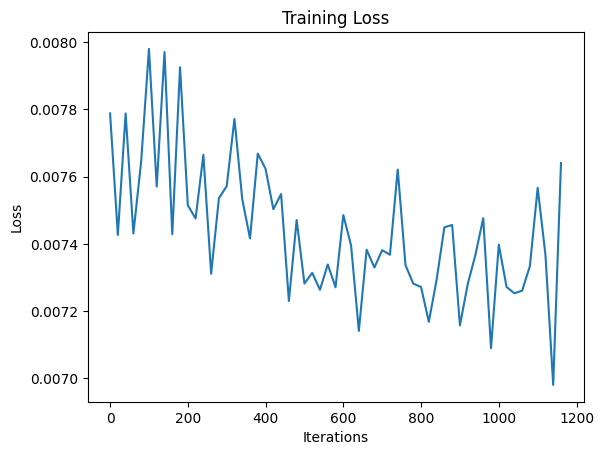

In [49]:
# Visualize your training curve
# ===== your code here! ====
iterations = range(0, len(train_losses), 20)
plt.plot(iterations, train_losses[::20])

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()
# ===== end of code ====

## Part 1.2.2: Out-of-Distribution Testing

In [55]:
# Visualize OOD testing
# ===== your code here! ====
sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
ex = test_dataset[np.random.randint(0, len(test_dataset))][0].unsqueeze(0).to(device)
noisy = []
denoised = []

for s in sigmas:
  noisy_image = ex + torch.randn_like(ex) * s
  denoised_image = model(noisy_image)
  noisy.append(noisy_image.detach().cpu().permute(0, 2, 3, 1).numpy()[0])
  denoised.append(denoised_image.detach().cpu().permute(0, 2, 3, 1).numpy()[0])

media.show_images(noisy, width=128, titles=[f"s={s}" for s in sigmas])
media.show_images(denoised, width=128)

s=0.0,s=0.2,s=0.4,s=0.5,s=0.6,s=0.8,s=1.0


,,,,,,


## Part 1.2.3 Denoising Pure Noise

In [56]:
# Feel free to use code from part 1.2.1
# as they should be very similar

device = torch.device('cuda')

batch_size = 256
learning_rate = 1e-4
hidden_dim = 128
num_epochs = 5

train_dataset = train
test_dataset = test
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=True)

model = UnconditionalUNet(1, hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

train_losses = []
train_epoch_losses = []
visualize_epochs = [0, 4]


for epoch in range(num_epochs):

  # train
  model.train()
  for i, (images, _) in enumerate(tqdm(train_loader, leave=False)):

    images = images.to(device)
    noise = torch.randn_like(images)
    noisy_images = noise
    outputs = model(noisy_images)

    loss = criterion(outputs, images)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

  train_epoch_losses.append(np.average(train_losses[epoch*len(train_loader):]))
  print(f"Epoch {epoch}: Training loss = {train_epoch_losses[-1]}")

  # visualize
  if epoch in visualize_epochs:
    model.eval()
    with torch.no_grad():
      idxs = np.random.randint(0, len(test_dataset), 3)

      ex = torch.stack([test_dataset[i][0] for i in idxs]).to(device)
      ex_n = torch.randn_like(ex) # pure noise
      ex_dn = model(ex_n) # noise denoised

      ex_n = ex_n.detach().cpu().permute(0, 2, 3, 1).numpy()
      ex_dn = ex_dn.detach().cpu().permute(0, 2, 3, 1).numpy()

      for i in range(3):
        if i == 0:
          media.show_images([ex_n[i], ex_dn[i]], width=128,
                            titles=["Noisy", "Denoised"])
        else:
          media.show_images([ex_n[i], ex_dn[i]], width=128)

Epoch 0: Training loss = 0.07330021750419698


Noisy,Denoised


,


,


Epoch 1: Training loss = 0.06753769580354081


Epoch 2: Training loss = 0.06746501814811788


Epoch 3: Training loss = 0.06744153049397976


Epoch 4: Training loss = 0.0673993505061941


Noisy,Denoised


,


,


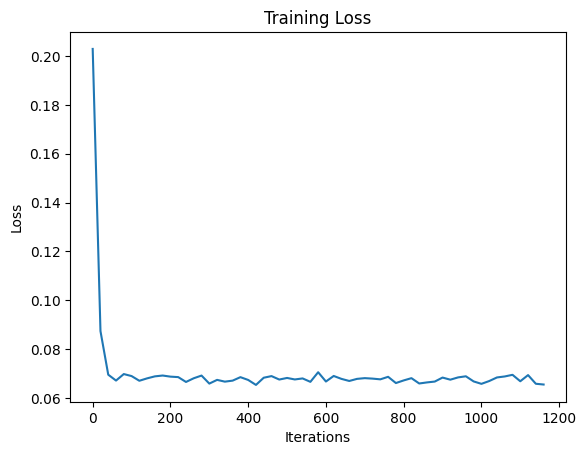

In [58]:
# Visualize your training curve
# ===== your code here! ====
iterations = range(0, len(train_losses), 20)
plt.plot(iterations, train_losses[::20])

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()
# ===== end of code ====

# Part 2: Flow Matching

# Part 2.1: Implementing a Time-conditioned UNet

In [59]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.net = nn.Sequential(
            nn.Linear(in_channels, out_channels),
            nn.GELU(),
            nn.Linear(out_channels, out_channels)
        )
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        self.num_hiddens  = num_hiddens
        self.num_classes  = num_classes
        self.ConvBlock1   = ConvBlock(in_channels, num_hiddens)
        self.DownBlock2   = DownBlock(num_hiddens, num_hiddens)
        self.DownBlock3   = DownBlock(num_hiddens, num_hiddens * 2)
        self.Flatten      = Flatten()
        self.Unflatten    = Unflatten(num_hiddens * 2)
        self.UpBlock4     = UpBlock(num_hiddens * 4, num_hiddens)
        self.UpBlock5     = UpBlock(num_hiddens * 2, num_hiddens)
        self.ConvBlock6   = ConvBlock(num_hiddens * 2, num_hiddens)
        self.out          = nn.Conv2d(num_hiddens, in_channels, kernel_size=3, stride=1, padding=1)
        self.fc1_t = FCBlock(1, 1)
        self.fc2_t = FCBlock(1, 1)
        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        t = t.unsqueeze(-1)
        t1 = self.fc1_t(t).view(-1, 1, 1, 1)
        t2 = self.fc2_t(t).view(-1, 1, 1, 1)

        layer1        = self.ConvBlock1(x)
        layer2        = self.DownBlock2(layer1)
        layer3        = self.DownBlock3(layer2)

        flattened     = self.Flatten(layer3)
        unflattened   = self.Unflatten(flattened)
        unflattened   = unflattened * t1 # new

        layer3        = torch.cat([unflattened, layer3], dim=1)
        layer3Up      = self.UpBlock4(layer3)
        layer3Up      = layer3Up * t2 # new

        layer2        = torch.cat([layer2, layer3Up], dim=1)
        layer2Up      = self.UpBlock5(layer2)

        layer1        = torch.cat([layer1, layer2Up], dim=1)
        layer1        = self.ConvBlock6(layer1)

        out = self.out(layer1)
        return out
        # ===== end of code ====

## Implementing the Forward and Reverse Process for Time-conditioned Denoising

In [60]:
def time_fm_forward(
    unet: TimeConditionalUNet,
    x_1: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1

    Args:
        unet: TimeConditionalUNet
        x_1: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    N = x_1.shape[0]
    t = torch.rand(N, device=device)
    x_0 = torch.randn_like(x_1)
    t_view = t.view(-1, 1, 1, 1)
    x_t = (1 - t_view) * x_0 + t_view * x_1
    target_flow = x_1 - x_0
    pred_flow = unet(x_t, t)
    loss = nn.functional.mse_loss(pred_flow, target_flow)
    return loss
    # ===== end of code ====

In [67]:
@torch.inference_mode()
def time_fm_sample(
    unet: TimeConditionalUNet,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2

    Args:
        unet: TimeConditionalUNet
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()
    # ===== your code here! ====
    H, W = img_wh
    N_samples = 40
    C = 1

    x = torch.randn(N_samples, C, H, W, device=device)
    dt = 1.0 / num_ts

    for i in range(num_ts):
      t_val = i / num_ts
      t = torch.full((N_samples,), t_val, device=device, dtype=torch.float32)
      v_pred = unet(x, t)
      x = x + v_pred * dt

    return x
    # ===== end of code ====

In [62]:
class TimeConditionalFM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        num_ts: int = 50,
        img_hw: tuple[int, int] = (28, 28),
    ):
        super().__init__()

        self.unet = unet
        self.num_ts = num_ts
        self.img_hw = img_hw


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return time_fm_forward(
            self.unet, x, self.num_ts
        )


    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return time_fm_sample(
            self.unet, img_wh, self.num_ts, seed
        )


# Part 2.2: Training the Time-conditioned UNet

In [71]:
# Feel free to use code from part 1.2.1
# as they should be very similar

batch_size = 64
lr = 1e-2
hidden_dim = 64
N_epochs = 10
gamma = 0.1 ** (1.0 / N_epochs)

train_dataset = train
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)

unet = TimeConditionalUNet(1, num_classes=10, num_hiddens=hidden_dim).to(device)
model2_2 = TimeConditionalFM(unet).to(device)

optimizer2_2 = torch.optim.Adam(model2_2.parameters(), lr=lr)
scheduler2_2 = torch.optim.lr_scheduler.ExponentialLR(optimizer2_2, gamma)

train_losses = []
train_epoch_losses = []
visualize_epochs = [0, 4, 9] # 1st, 5th, 10th

for epoch in range(N_epochs):

  # train
  model2_2.train()
  for i, (images, _) in enumerate(tqdm(train_loader)):

    images = images.to(device)
    loss = model2_2(images)

    optimizer2_2.zero_grad()
    loss.backward()
    optimizer2_2.step()

    train_losses.append(loss.item())

  train_epoch_losses.append(np.average(train_losses[epoch*len(train_loader):]))
  print(f"Epoch {epoch+1}: Training loss = {train_epoch_losses[-1]}")

  scheduler2_2.step()

  if epoch in visualize_epochs:
    model2_2.eval()
    with torch.no_grad():
      samples = model2_2.sample(img_wh=(28, 28))
      samples = samples.detach().cpu().permute(0, 2, 3, 1).numpy()

      print(f"\nSampling results after Epoch {epoch+1}:")
      for i in range(4):
        media.show_images(samples[i*10: (i+1)*10], width=50)
      print()

100%|██████████| 938/938 [00:42<00:00, 22.25it/s]


Epoch 1: Training loss = 0.17954723972247352

Sampling results after Epoch 1:


,,,,,,,,,


,,,,,,,,,


,,,,,,,,,


,,,,,,,,,


100%|██████████| 938/938 [00:41<00:00, 22.67it/s]


Epoch 2: Training loss = 0.12301721678041955


100%|██████████| 938/938 [00:41<00:00, 22.48it/s]


Epoch 3: Training loss = 0.1122546656839629


100%|██████████| 938/938 [00:41<00:00, 22.61it/s]


Epoch 4: Training loss = 0.10680347164747303


100%|██████████| 938/938 [00:41<00:00, 22.45it/s]


Epoch 5: Training loss = 0.1026634152875399

Sampling results after Epoch 5:


,,,,,,,,,


,,,,,,,,,


,,,,,,,,,


,,,,,,,,,


100%|██████████| 938/938 [00:41<00:00, 22.53it/s]


Epoch 6: Training loss = 0.10046194854385054


100%|██████████| 938/938 [00:41<00:00, 22.47it/s]


Epoch 7: Training loss = 0.09797581659355906


100%|██████████| 938/938 [00:41<00:00, 22.53it/s]


Epoch 8: Training loss = 0.09669867917291645


100%|██████████| 938/938 [00:41<00:00, 22.46it/s]


Epoch 9: Training loss = 0.09496636018315867


100%|██████████| 938/938 [00:41<00:00, 22.53it/s]


Epoch 10: Training loss = 0.09374333550331435

Sampling results after Epoch 10:


,,,,,,,,,


,,,,,,,,,


,,,,,,,,,


,,,,,,,,,


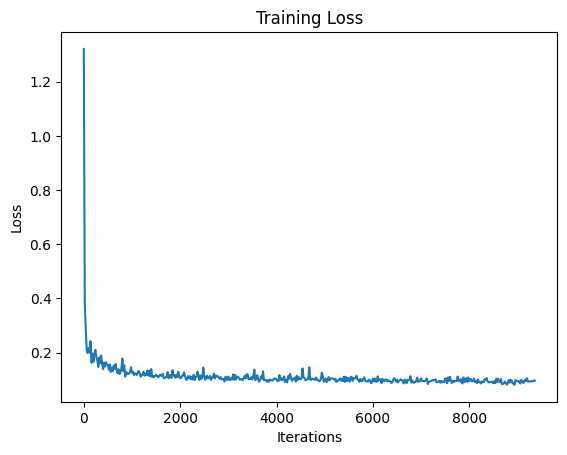

In [72]:
# Visualize your training curve
# ===== your code here! ====
iterations = range(0, len(train_losses), 20)
plt.plot(iterations, train_losses[::20])

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()
# ===== end of code ====

# Part 2.3: Sampling from the Time-conditioned UNet

In [86]:
# see output from part 2.2

# Part 2.4: Implementing a Class-conditioned UNet

In [75]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        self.num_hiddens  = num_hiddens
        self.num_classes  = num_classes
        self.ConvBlock1   = ConvBlock(in_channels, num_hiddens)
        self.DownBlock2   = DownBlock(num_hiddens, num_hiddens)
        self.DownBlock3   = DownBlock(num_hiddens, num_hiddens * 2)
        self.Flatten      = Flatten()
        self.Unflatten    = Unflatten(num_hiddens * 2)
        self.UpBlock4     = UpBlock(num_hiddens * 4, num_hiddens)
        self.UpBlock5     = UpBlock(num_hiddens * 2, num_hiddens)
        self.ConvBlock6   = ConvBlock(num_hiddens * 2, num_hiddens)
        self.out          = nn.Conv2d(num_hiddens, in_channels, kernel_size=3, stride=1, padding=1)
        self.fc1_t = FCBlock(1, 1)
        self.fc2_t = FCBlock(1, 1)
        self.fc1_c = FCBlock(num_classes, num_hiddens * 2)
        self.fc2_c = FCBlock(num_classes, num_hiddens)
        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        t = t.unsqueeze(-1)
        t1 = self.fc1_t(t).view(-1, 1, 1, 1)
        t2 = self.fc2_t(t).view(-1, 1, 1, 1)

        c_onehot = nn.functional.one_hot(c, self.num_classes).float().to(device)
        if mask is not None:
            c_onehot = c_onehot * mask.unsqueeze(1)
        c1 = self.fc1_c(c_onehot).view(-1, self.num_hiddens * 2, 1, 1)
        c2 = self.fc2_c(c_onehot).view(-1, self.num_hiddens, 1, 1)

        layer1        = self.ConvBlock1(x)
        layer2        = self.DownBlock2(layer1)
        layer3        = self.DownBlock3(layer2)

        flattened     = self.Flatten(layer3)
        unflattened   = self.Unflatten(flattened)
        unflattened   = c1 * unflattened * t1 # new

        layer3        = torch.cat([unflattened, layer3], dim=1)
        layer3Up      = self.UpBlock4(layer3)
        layer3Up      = c2 * layer3Up * t2 # new

        layer2        = torch.cat([layer2, layer3Up], dim=1)
        layer2Up      = self.UpBlock5(layer2)

        layer1        = torch.cat([layer1, layer2Up], dim=1)
        layer1        = self.ConvBlock6(layer1)

        out = self.out(layer1)
        return out
        # ===== end of code ====

In [81]:
def class_fm_forward(
    unet: ClassConditionalUNet,
    x_1: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 3

    Args:
        unet: ClassConditionalUNet
        x_1: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    N = x_1.shape[0]
    t = torch.rand(N, device=device)
    x_0 = torch.randn_like(x_1)
    t_view = t.view(-1, 1, 1, 1)
    x_t = (1 - t_view) * x_0 + t_view * x_1
    mask_prob = 1 - p_uncond
    mask = torch.bernoulli(torch.full((N,), mask_prob, device=device)).float()
    target_flow = x_1 - x_0
    pred_flow = unet(x_t, c, t, mask)
    loss = nn.functional.mse_loss(pred_flow, target_flow)
    return loss
    # ===== end of code ====
    raise NotImplementedError()

In [82]:
@torch.inference_mode()
def class_fm_sample(
    unet: ClassConditionalUNet,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 4

    Args:
        unet: ClassConditionalUNet
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()
    # ===== your code here! ====
    N = c.shape[0]
    H, W = img_wh
    C = 1

    x = torch.randn(N, C, H, W, device=device)
    cache = []
    dt = 1.0 / num_ts

    for i in range(num_ts):
      t_val = i / num_ts
      t = torch.full((N,), t_val, device=device, dtype=torch.float32)

      mask_uncond = torch.zeros(N, device=device)
      v_uncond = unet(x, c, t, mask_uncond)
      mask_cond = torch.ones(N, device=device)
      v_cond = unet(x, c, t, mask_cond)

      v_pred = v_uncond + guidance_scale * (v_cond - v_uncond)
      x = x + v_pred * dt
      cache.append(x.detach().cpu())

    cache_t = torch.stack(cache).permute(1, 0, 2, 3, 4)
    return x, cache_t
    # ===== end of code ====

In [83]:
class ClassConditionalFM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) loss.
        """
        return class_fm_forward(
            self.unet, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return class_fm_sample(
            self.unet, c, img_wh, self.num_ts, guidance_scale, seed
        )

# Part 2.5 Training the Class-conditioned UNet

In [87]:
# Feel free to use code from part 1.2.1
# as they should be very similar

# Feel free to use code from part 1.2.1
# as they should be very similar

batch_size = 64
lr = 1e-2
hidden_dim = 64
N_epochs = 10
gamma = 0.1 ** (1.0 / N_epochs)

train_dataset = train
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)

unet = ClassConditionalUNet(1, num_classes=10, num_hiddens=hidden_dim).to(device)
model2_5 = ClassConditionalFM(unet).to(device)

optimizer2_5 = torch.optim.Adam(model2_5.parameters(), lr=lr)
scheduler2_5 = torch.optim.lr_scheduler.ExponentialLR(optimizer2_5, gamma)

train_losses = []
train_epoch_losses = []
visualize_epochs = [0, 4, 9] # 1st, 5th, 10th

for epoch in range(N_epochs):

  # train
  model2_5.train()
  for i, (images, labels) in enumerate(tqdm(train_loader)):

    images = images.to(device)
    labels = labels.to(device)
    loss = model2_5(images, labels)

    optimizer2_5.zero_grad()
    loss.backward()
    optimizer2_5.step()

    train_losses.append(loss.item())

  train_epoch_losses.append(np.average(train_losses[epoch*len(train_loader):]))
  print(f"Epoch {epoch+1}: Training loss = {train_epoch_losses[-1]}")

  scheduler2_5.step()

  if epoch in visualize_epochs:
    model2_5.eval()
    with torch.no_grad():
      sample_labels = torch.arange(10).repeat(4).to(device)
      samples, _ = model2_5.sample(img_wh=(28, 28), c=sample_labels)
      samples = samples.detach().cpu().permute(0, 2, 3, 1).numpy()

      print(f"\nSampling results after Epoch {epoch+1}:")
      for i in range(4):
        media.show_images(samples[i*10: (i+1)*10], width=50)
      print()

100%|██████████| 938/938 [00:42<00:00, 22.13it/s]


Epoch 1: Training loss = 0.1749349648970912

Sampling results after Epoch 1:


,,,,,,,,,


,,,,,,,,,


,,,,,,,,,


,,,,,,,,,


100%|██████████| 938/938 [00:42<00:00, 22.12it/s]


Epoch 2: Training loss = 0.11105020720757909


100%|██████████| 938/938 [00:44<00:00, 21.32it/s]


Epoch 3: Training loss = 0.09997081243470787


100%|██████████| 938/938 [00:42<00:00, 22.31it/s]


Epoch 4: Training loss = 0.09565750998792363


100%|██████████| 938/938 [00:42<00:00, 22.23it/s]


Epoch 5: Training loss = 0.09194689155864055

Sampling results after Epoch 5:


,,,,,,,,,


,,,,,,,,,


,,,,,,,,,


,,,,,,,,,


100%|██████████| 938/938 [00:42<00:00, 22.17it/s]


Epoch 6: Training loss = 0.08950947177435543


100%|██████████| 938/938 [00:42<00:00, 22.23it/s]


Epoch 7: Training loss = 0.08778899781771306


100%|██████████| 938/938 [00:42<00:00, 22.16it/s]


Epoch 8: Training loss = 0.08682405599939035


100%|██████████| 938/938 [00:42<00:00, 22.24it/s]


Epoch 9: Training loss = 0.08527483526609346


100%|██████████| 938/938 [00:42<00:00, 22.18it/s]


Epoch 10: Training loss = 0.08431849935288623

Sampling results after Epoch 10:


,,,,,,,,,


,,,,,,,,,


,,,,,,,,,


,,,,,,,,,


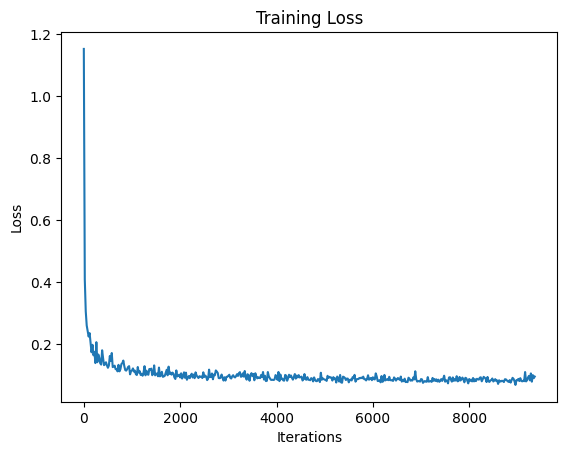

In [89]:
# Visualize your training curve
# ===== your code here! ====
iterations = range(0, len(train_losses), 20)
plt.plot(iterations, train_losses[::20])

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()
# ===== end of code ====

# Part 2.6: Sampling from the Class-conditioned UNet

In [85]:
# see output from part 2.5